In this notebook we train two models (model_start and model_end) and then a third model_theta.

In [ ]:
import torch
import torch.nn as nn
from scheduler import make_diy_scheduler
from torch.utils.data import DataLoader
from train import train
from curve_model import Curve
import os
import matplotlib.pyplot as plt
from curve_plots import plot_Curve_losslandscape, bezier_plot
from curve_eval import curve_eval_regression
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
#from getdata import make_loaders, torch_seed, gen_model_data, gen_log_regression_data, get_dataloader_scipy
from contextlib import contextmanager

In [2]:

@contextmanager
def torch_seed(seed):
    """
    A context manager to temporarily set the random seed in PyTorch.
    
    Args:
        seed (int): The seed value to use within the context.
    """
    # Save the current random state
    random_state = torch.get_rng_state()
    try:
        torch.manual_seed(seed)
        yield
    finally:
        # Restore the previous random state
        torch.set_rng_state(random_state)


In [ ]:
# Set device, data paths, and other global variables
device="cpu"

root = ".."
datafolder = f"{root}/data"
base_directory = f"{root}/experiments/results_notebook_function"
batch_size = 40

# Set random seed for reproducibility
torch.manual_seed(0)

In [ ]:

# Define a simple feedforward neural network for function approximation
class FunctionApproximatorModel(torch.nn.Module):
    def __init__(self, num_features=1, hidden_layers=[10], num_outputs=1, nonlin = torch.nn.ReLU(), seed=2):
        super(FunctionApproximatorModel, self).__init__()
        with torch_seed(seed):
            self.layers = [num_features] + hidden_layers + [num_outputs]
            self.hidden_layers = nn.ModuleList([nn.Linear(self.layers[i], self.layers[i+1]) for i in range(len(self.layers)-1)])
            self.nonlin = nonlin
            for layer in self.hidden_layers:
                torch.nn.init.kaiming_normal_(layer.weight)
                #torch.nn.init.constant_(layer.bias, 0.0)
    def forward(self, x):
        for layer in self.hidden_layers[:-1]:
            x = self.nonlin(layer(x))
        return self.hidden_layers[-1](x)

num_features=1
# Instantiate the model with the specified architecture and random seed
UFA_model = FunctionApproximatorModel(num_features=num_features, hidden_layers=[10,10], num_outputs=1, nonlin = torch.nn.Tanh(), seed=47)

# We make a function that returns a function that returns a model with specific kargs.
# This will be used in the mode connectivity code to create new instances of the model 
# with the a specific architecture and random seed.
MODEL = FunctionApproximatorModel
def return_model(MODEL, **model_kargs):
    return lambda: MODEL(**model_kargs)

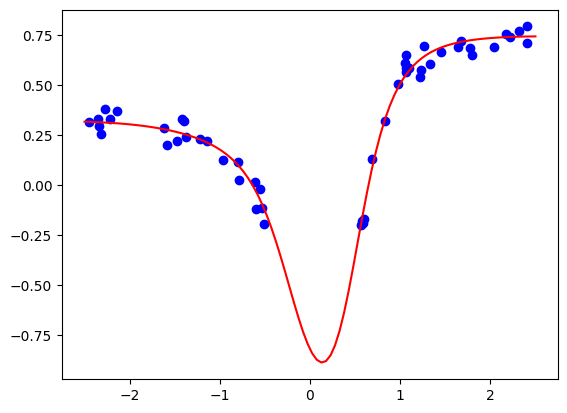

torch.Size([100, 1])


In [ ]:

# Build data loaders for training and testing
def make_loaders(X, y, train_size, batch_size=0):
    indices = torch.randperm(len(X))
    X_ = X[indices]
    y_ = y[indices]
    X_train, X_test = X_[:train_size], X_[train_size:]
    y_train, y_test = y_[:train_size], y_[train_size:]

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)
    if batch_size == 0:
        batch_size = max(len(train_dataset), len(test_dataset))
    train_loader = DataLoader(train_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    return train_loader, test_loader
    
# function that takes a model, some observation noise, and generates data
def gen_model_data(model, input_dist, num_train_samples=10, 
                                   num_test_samples=10, noise_std=None, output_dist = None, seed=2, batch_size=0):
    N = num_train_samples + num_test_samples
    if output_dist == None:
        output_dist = lambda x: torch.distributions.Normal(x, noise_std)
    with torch_seed(seed):
        X = input_dist(N)
        modelout = model(X).detach()
        #print(f"{modelout.shape = }")
        #y = modelout + torch.randn_like(modelout) * noise_std
        y = output_dist(modelout).sample()
        #print(f"{y.shape = }")
        #print(f"{X.shape = }")
    return make_loaders(X, y, num_train_samples, batch_size=batch_size)

prior_sigma = 1.
target_sigma = 0.05

start_x = -2.5
end_x = 2.5

# Distribution of inputs for training and testing. We sample uniformly from the interval [start_x, end_x], 
# but we remove points in the interval [-0.5, 0.5] so that we can see how the sampled models behave outside of the training data.
def input_dist(N):
    xs = torch.rand(N*10, num_features)*(end_x-start_x) + start_x
    index = (1-((xs > -.5) & (xs < 0.5)).int()).nonzero()[:,0]
    return xs[index][:N]

train_loader, test_loader = gen_model_data(UFA_model, input_dist, num_train_samples=50, 
                                           num_test_samples=10, noise_std=target_sigma, seed=2, batch_size=batch_size)

xs, ys = train_loader.dataset.tensors
xs_plt = torch.linspace(start_x, end_x, 100).unsqueeze(1)
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
ys_plt_pretrained = UFA_model(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, c="r", label="true function")
plt.show()
dataset = "function"

In [6]:
def NegLogLik_regression(target_sigma=1.0):
    def fn(pred, target):
        #loss = (pred - target).pow(2).sum()/(2 * target_sigma**2)
        loss = torch.nn.MSELoss(reduction="mean")(pred, target)/(2 * target_sigma**2)
        return loss
    return fn

loss_fn = NegLogLik_regression(target_sigma)
batch_size = 30
#num_features=num_features, hidden_layers=[10,10], num_outputs=1, nonlin = torch.nn.Tanh(), seed=47#


In [7]:
os.makedirs(f"{base_directory}/models", exist_ok=True)
os.makedirs(f"{base_directory}/figures", exist_ok=True)


retrain=True
if retrain:
    model_lr_start = torch.tensor(0.001)
    model_lr_end = torch.tensor(0.001)
    model_epochs = 2000

    total_iter = model_epochs*train_loader.__len__()
    model_kargs = {"num_features": num_features, "hidden_layers": [10,10], "num_outputs": 1, "nonlin": torch.nn.Tanh(), "seed": 3}
    model_start = return_model(MODEL, **model_kargs)().to(device)
    optimizer_start = torch.optim.Adam(params=model_start.parameters(), lr=model_lr_start.clone())
    scheduler_start = make_diy_scheduler(optimizer_start, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_start, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_start, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_start, 
                                                scheduler=scheduler_start, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/start_model/figures",
                                                verbose=True, print_every_n_epoch=50
                                                )
    torch.save(model_start, f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth")
    #for k in plots.keys():
    #    display(plots[k][0])
else:
    model_start = torch.load(f"{base_directory}/models/model_start_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

epoch = 50 	train loss: 93.87414, test loss: 52.45702, test accuracy: 0.00, lr: 1.000000e-03
epoch = 100 	train loss: 14.22558, test loss: 11.64742, test accuracy: 0.00, lr: 1.000000e-03
epoch = 150 	train loss: 7.02335, test loss: 6.29589, test accuracy: 0.00, lr: 1.000000e-03
epoch = 200 	train loss: 3.10725, test loss: 2.49121, test accuracy: 0.00, lr: 1.000000e-03
epoch = 250 	train loss: 1.47459, test loss: 1.06232, test accuracy: 0.00, lr: 1.000000e-03
epoch = 300 	train loss: 1.05126, test loss: 0.91992, test accuracy: 0.00, lr: 1.000000e-03
epoch = 350 	train loss: 0.96228, test loss: 1.01399, test accuracy: 0.00, lr: 1.000000e-03
epoch = 400 	train loss: 0.91175, test loss: 1.04099, test accuracy: 0.00, lr: 1.000000e-03
epoch = 450 	train loss: 0.85917, test loss: 1.01090, test accuracy: 0.00, lr: 1.000000e-03
epoch = 500 	train loss: 0.80911, test loss: 0.96202, test accuracy: 0.00, lr: 1.000000e-03
epoch = 550 	train loss: 0.76514, test loss: 0.91213, test accuracy: 0.00, lr

cpu


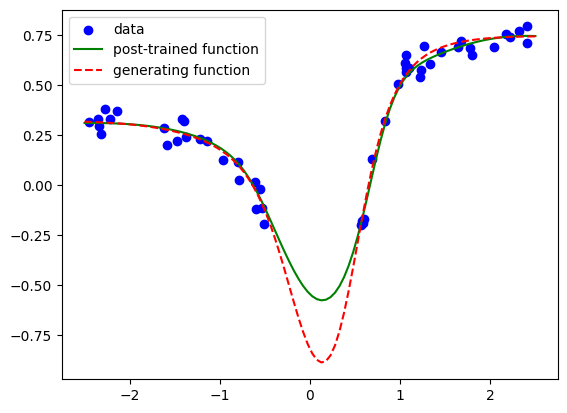

In [8]:
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
print(xs_plt.device)
ys_plt_trained = model_start(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="g", label="post-trained function")
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, label="generating function", linestyle="--", c="r")
plt.legend()
#plt.savefig(f"{fig_folder}/post_trained_function.png")

In [9]:
if retrain:
    model_lr_start = torch.tensor(0.001)
    model_lr_end = torch.tensor(0.001)
    model_epochs = 2000

    total_iter = model_epochs*train_loader.__len__()

    model_kargs = {"num_features": num_features, "hidden_layers": [10,10], "num_outputs": 1, "nonlin": torch.nn.Tanh(), "seed": 2}
    model_end = return_model(MODEL, **model_kargs)().to(device)
    optimizer_end = torch.optim.Adam(params=model_end.parameters(), lr=model_lr_start.clone())
    scheduler_end = make_diy_scheduler(optimizer_end, 
                                             train_num_steps=total_iter, 
                                             lr_start_warmup=model_lr_start.clone(), 
                                             lr=model_lr_end.clone(), 
                                             lr_warmup_steps=5*train_loader.__len__(), 
                                             lr_finetune_halftime=total_iter // (5*3), 
                                             lr_finetune_steps=total_iter // 3
            )
    model_end, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(model_end, 
                                                train_loader=train_loader, 
                                                test_loader=test_loader, 
                                                optimizer=optimizer_end, 
                                                scheduler=scheduler_end, 
                                                epochs=model_epochs, loss_fn=loss_fn, device=device, 
                                                plot=True, plotpath=f"{base_directory}/end_model/figures",
                                                verbose=True, print_every_n_epoch=50
                                                )
    torch.save(model_end, f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth")
    #for k in plots.keys():
    #    display(plots[k][0])
else:
    model_end = torch.load(f"{base_directory}/models/model_end_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)

epoch = 50 	train loss: 15.64256, test loss: 13.59791, test accuracy: 0.00, lr: 1.000000e-03
epoch = 100 	train loss: 5.69268, test loss: 4.83524, test accuracy: 0.00, lr: 1.000000e-03
epoch = 150 	train loss: 1.38822, test loss: 1.11917, test accuracy: 0.00, lr: 1.000000e-03
epoch = 200 	train loss: 0.77052, test loss: 0.67528, test accuracy: 0.00, lr: 1.000000e-03
epoch = 250 	train loss: 0.67815, test loss: 0.61228, test accuracy: 0.00, lr: 1.000000e-03
epoch = 300 	train loss: 0.63505, test loss: 0.57951, test accuracy: 0.00, lr: 1.000000e-03
epoch = 350 	train loss: 0.60563, test loss: 0.55733, test accuracy: 0.00, lr: 1.000000e-03
epoch = 400 	train loss: 0.58386, test loss: 0.54151, test accuracy: 0.00, lr: 1.000000e-03
epoch = 450 	train loss: 0.56704, test loss: 0.52953, test accuracy: 0.00, lr: 1.000000e-03
epoch = 500 	train loss: 0.55350, test loss: 0.51982, test accuracy: 0.00, lr: 1.000000e-03
epoch = 550 	train loss: 0.54218, test loss: 0.51147, test accuracy: 0.00, lr: 

cpu


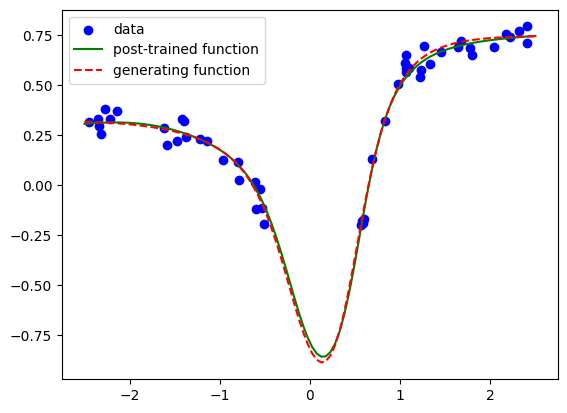

In [10]:
plt.scatter(xs[:, 0].detach(), ys.detach(), c="b", label="data")
print(xs_plt.device)
ys_plt_trained = model_end(xs_plt).detach()
plt.plot(xs_plt[:, 0].detach(), ys_plt_trained, c="g", label="post-trained function")
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, label="generating function", linestyle="--", c="r")
plt.legend()
#plt.savefig(f"{fig_folder}/post_trained_function.png")

In [11]:
def curve_fn(param_start, param_end, param_theta, t):
    return param_start * (1-t)**2 + param_end * t**2 + param_theta * 2*t*(1-t)

In [12]:
retrain_curve = True
curve_epochs= 4000
curve_lr_start = torch.tensor(1e-7)
curve_lr_end = torch.tensor(1e-6)
curve_optimizer = "SGD"
total_iter = curve_epochs*train_loader.__len__()

epoch = 50 	train loss: 8.57456, test loss: 49.50541, test accuracy: 0.00, lr: 1.000000e-06
epoch = 100 	train loss: 46.39637, test loss: 36.58823, test accuracy: 0.00, lr: 1.000000e-06
epoch = 150 	train loss: 35.77647, test loss: 38.36979, test accuracy: 0.00, lr: 1.000000e-06
epoch = 200 	train loss: 13.79521, test loss: 0.53372, test accuracy: 0.00, lr: 1.000000e-06
epoch = 250 	train loss: 5.86726, test loss: 32.21150, test accuracy: 0.00, lr: 1.000000e-06
epoch = 300 	train loss: 23.03832, test loss: 18.84778, test accuracy: 0.00, lr: 1.000000e-06
epoch = 350 	train loss: 27.85604, test loss: 9.14897, test accuracy: 0.00, lr: 1.000000e-06
epoch = 400 	train loss: 18.63310, test loss: 3.56899, test accuracy: 0.00, lr: 1.000000e-06
epoch = 450 	train loss: 1.84563, test loss: 6.54846, test accuracy: 0.00, lr: 1.000000e-06
epoch = 500 	train loss: 7.08554, test loss: 22.43915, test accuracy: 0.00, lr: 1.000000e-06
epoch = 550 	train loss: 18.95410, test loss: 8.75740, test accuracy:

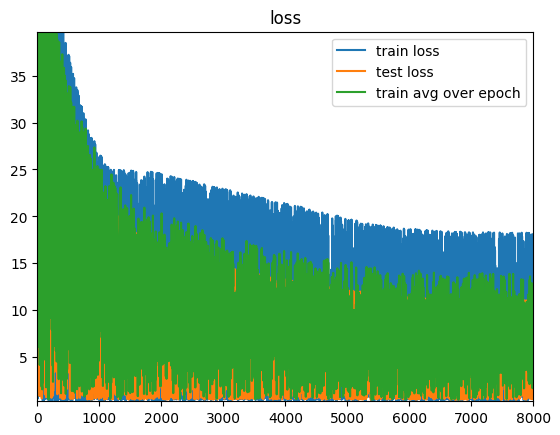

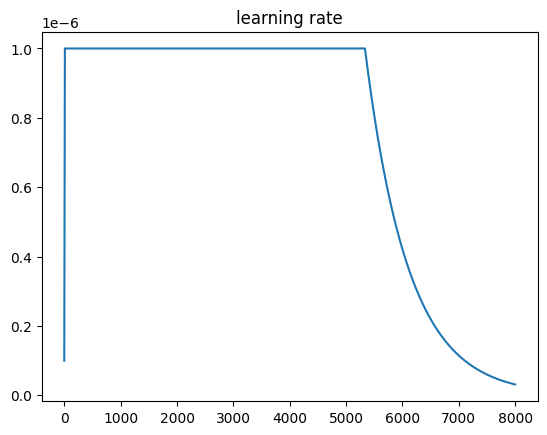

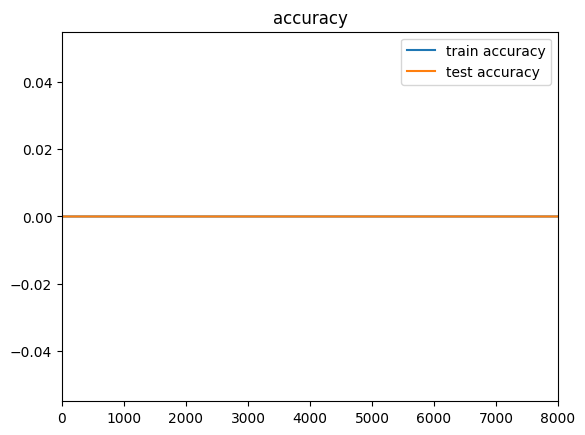

In [13]:

model_kargs = {"num_features": num_features, "hidden_layers": [10,10], "num_outputs": 1, "nonlin": torch.nn.Tanh(), "seed": 7}
    
if retrain_curve:
    total_iter = curve_epochs*train_loader.__len__()
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device, model_maker=return_model(MODEL, **model_kargs))
    gamma = ((curve_lr_end.log()-curve_lr_start.log())/(curve_epochs*train_loader.__len__())).exp()

    optimizer = torch.optim.SGD(params=curve.model_theta.parameters(), lr=curve_lr_start, momentum=0.9)

    scheduler = make_diy_scheduler(optimizer, 
                                            train_num_steps=total_iter, 
                                            lr_start_warmup=curve_lr_start.clone(), 
                                            lr=curve_lr_end.clone(), 
                                            lr_warmup_steps=5*train_loader.__len__(), 
                                            lr_finetune_halftime=total_iter // (5*3), 
                                            lr_finetune_steps=total_iter // 3
        )
            

    curve, all_train_losses, lrs, epoch_train_losses, test_losses, epoch_train_accuracy, plots = train(curve, 
                                                                        train_loader=train_loader, 
                                                                        test_loader=test_loader, 
                                                                        optimizer=optimizer, 
                                                                        scheduler=scheduler, 
                                                                        epochs=curve_epochs,
                                                                        loss_fn=loss_fn, 
                                                                        device=device, 
                                                                        plot=True, 
                                                                        plotpath=f"{base_directory}/curve_model/figures", 
                                                                        #plotname=f"curvefitting_{MODEL.__name__}_{dataset}", 
                                                                        modeltype="curve", 
                                                                        print_every_n_epoch=50,
                                                                        verbose=True)
    torch.save(curve.model_theta, f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth")
    for k in plots.keys():
        display(plots[k][0])
else:
    curve = Curve(model_start=model_start, model_end=model_end, curve_fn=curve_fn, device=device, model_maker=return_model(MODEL, **model_kargs))
    curve.model_theta = torch.load(f"{base_directory}/models/curve.model_theta_{MODEL.__name__}_{dataset}.pth", map_location=torch.device(device), weights_only=False)
    

In [14]:
metrics_dict = {
    "loss": loss_fn,
    "MSE": torch.nn.MSELoss(reduction="mean"),
}



begin loss landscape plot
begin calculation of mesh for loss landscape plot
finished loss landscape plotest_loss = 710.46336669921886



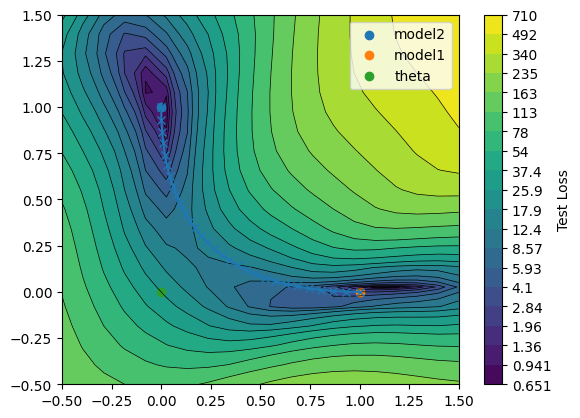

In [15]:
model_kargs = {"num_features": num_features, "hidden_layers": [10,10], "num_outputs": 1, "nonlin": torch.nn.Tanh(), "seed": 4}

fig, ax = plot_Curve_losslandscape(curve, device, f"{base_directory}/figures", train_loader, N_points=20, loss_fn=loss_fn, recalc_mesh=True, N_bezierpoints=30, model_maker=return_model(MODEL, **model_kargs))
fig.savefig(f"{base_directory}/figures/loss_landscape.png")
plt.show(fig)


begin evaluation of curve
N_obs = 10
loss start model: 0.5368103981018066
loss end mode: 0.4544914662837982
loss ensemble: 4.547262191772461
MSE start model: 0.0026840518694370985
MSE end mode: 0.0022724573500454426
MSE ensemble: 0.022736310958862305
finished evaluation of curve



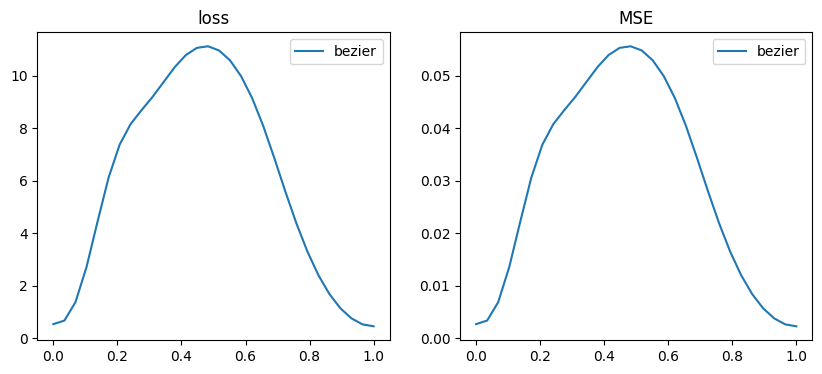

In [16]:
samplesize = 30
model_kargs = {"num_features": num_features, "hidden_layers": [10,10], "num_outputs": 1, "nonlin": torch.nn.Tanh(), "seed": 4}
ts = torch.linspace(0, 1, samplesize)
perpoint_score_dict, ts, ensemble_measurement_dict, all_predictions, true_y = curve_eval_regression(curve, ts= ts,  test_loader=test_loader, device=device, logger_info=print, eval_straight_line=False, verbose=False, metrics_dict=metrics_dict, model_maker=return_model(MODEL, **model_kargs))
eval_results = {"curve_perpoint_score_dict": perpoint_score_dict, "ts": ts, "curve_ensemble_score_dict": ensemble_measurement_dict}
fig, axs, eval_results = bezier_plot(curve, device, test_loader=train_loader, 
                                     plottype="linear", eval_results=eval_results,
                        N_bezierpoints = 30,
                        plot_linear=False, metrics_dict=metrics_dict, 
                        classification_task=False, 
                        model_maker=return_model(MODEL, **model_kargs))


In [17]:
print(pd.DataFrame(eval_results["curve_ensemble_score_dict"]).T.reset_index().rename(columns={"index": "Model"}).to_markdown(index=False))

| Model       |     loss |        MSE |
|:------------|---------:|-----------:|
| Start model | 0.53681  | 0.00268405 |
| End model   | 0.454491 | 0.00227246 |
| Ensemble    | 4.54726  | 0.0227363  |


In [18]:
# make a dataloader that loads xs_plt, ys_plt_pretrained in one batch:
dataset = TensorDataset(xs_plt, ys_plt_pretrained)
dataloader = DataLoader(dataset, batch_size=len(dataset))


In [19]:

perpoint_score_dict, ts, ensemble_measurement_dict, all_predictions, true_y = curve_eval_regression(curve, ts= ts,  test_loader=dataloader, device=device, logger_info=print, eval_straight_line=False, verbose=False, metrics_dict=metrics_dict, model_maker=return_model(MODEL, **model_kargs))

print(xs_plt.shape)
print(all_predictions.shape)



begin evaluation of curve
N_obs = 100
loss start model: 1.7122353315353394
loss end mode: 0.04489447548985481
loss ensemble: 15.520977973937988
MSE start model: 0.008561176247894764
MSE end mode: 0.0002244723727926612
MSE ensemble: 0.07760488986968994
finished evaluation of curve

torch.Size([100, 1])
torch.Size([100, 30, 1])


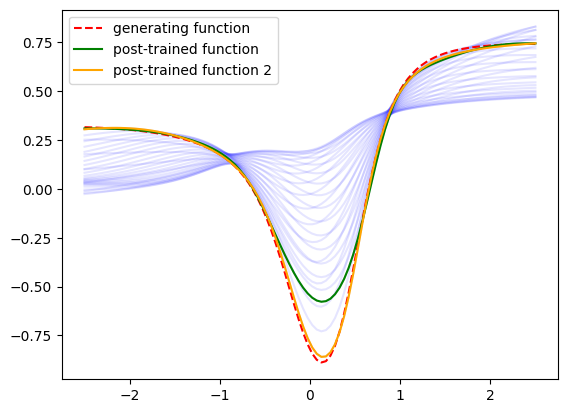

In [20]:

_=plt.plot(xs_plt[:,:].expand([100,30]).detach(), all_predictions[:,:,0], c="b", alpha=0.1)
plt.plot(xs_plt[:, 0].detach(), ys_plt_pretrained, c="r", label="generating function", linestyle="--")
plt.plot(xs_plt[:, 0].detach(), model_start(xs_plt).detach(), c="g", label="post-trained function")
plt.plot(xs_plt[:, 0].detach(), model_end(xs_plt).detach(), c="orange", label="post-trained function 2")
plt.legend()
plt.show()